Single Tree - Train acc: 1.000
Single Tree - Test  acc: 0.850

Bagging    - Train acc: 1.000
Bagging    - Test  acc: 0.917
Bagging    - OOB  acc: 0.892


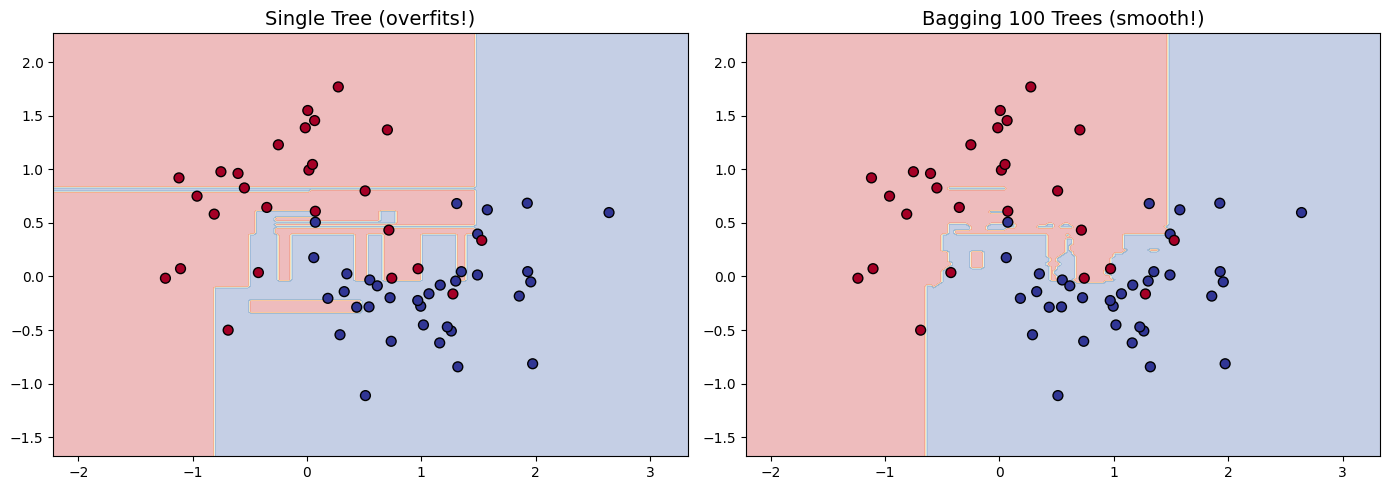

DONE! Notice how the single tree has jagged boundaries (overfit)
while bagging has smooth boundaries (generalizes better).


In [1]:
# ============================================================
# Ex1: WHY BAGGING WORKS — Single Tree vs Bagging
# ============================================================
# Think of it like this:
# One student takes one exam → might get lucky or unlucky
# 100 students take the exam → average score is more reliable!

import numpy as np                    # math library
import matplotlib.pyplot as plt       # for drawing graphs
from sklearn.tree import DecisionTreeClassifier    # one tree
from sklearn.ensemble import BaggingClassifier     # many trees
from sklearn.datasets import make_moons            # toy dataset
from sklearn.model_selection import train_test_split

# --- STEP 1: Make some fake data (two half-moon shapes) ---
# n_samples=300: we want 300 data points
# noise=0.3: add some randomness so it's not perfect
# random_state=42: so you get the exact same data every time
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

# --- STEP 2: Split into training (80%) and test (20%) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- STEP 3: Train a SINGLE deep tree (will overfit!) ---
single_tree = DecisionTreeClassifier(random_state=42)  # no depth limit!
single_tree.fit(X_train, y_train)
print(f"Single Tree - Train acc: {single_tree.score(X_train, y_train):.3f}")
print(f"Single Tree - Test  acc: {single_tree.score(X_test, y_test):.3f}")
# You'll see: train acc ~1.000, test acc ~0.85-0.90 → OVERFITTING!

# --- STEP 4: Train BAGGING (100 trees, each on bootstrap sample) ---
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),  # base learner = tree
    n_estimators=100,     # 100 trees in the bag
    bootstrap=True,       # sample WITH replacement
    oob_score=True,       # use out-of-bag for free validation
    random_state=42,
    n_jobs=-1             # use all CPU cores (parallel!)
)
bag_clf.fit(X_train, y_train)
print(f"\nBagging    - Train acc: {bag_clf.score(X_train, y_train):.3f}")
print(f"Bagging    - Test  acc: {bag_clf.score(X_test, y_test):.3f}")
print(f"Bagging    - OOB  acc: {bag_clf.oob_score_:.3f}")
# You'll see: test acc ~0.90-0.95 → BETTER and more STABLE!

# --- STEP 5: Visualize the decision boundaries ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, clf, title in zip(
    axes,
    [single_tree, bag_clf],
    ["Single Tree (overfits!)", "Bagging 100 Trees (smooth!)"]
):
    # Create a mesh grid to plot decision regions
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdYlBu',
               edgecolors='black', s=50)
    ax.set_title(title, fontsize=14)

plt.tight_layout()
plt.savefig("ex1_bagging_vs_single_tree.png", dpi=100)
plt.show()
print("DONE! Notice how the single tree has jagged boundaries (overfit)")
print("while bagging has smooth boundaries (generalizes better).")

In [2]:
# ============================================================
# Ex3: ADABOOST FROM SCRATCH — 3 ROUNDS, ALL STEPS SHOWN
# ============================================================

# --- Tiny dataset (same as NUMERICAL P4) ---
X_tiny = np.array([[1,2], [2,1], [3,3], [4,2], [5,4]])
y_tiny = np.array([+1, +1, -1, -1, -1])
n = len(y_tiny)

print("DATASET:")
print(f"  X = {X_tiny.tolist()}")
print(f"  y = {y_tiny.tolist()}")
print()

# --- Initialize ---
w = np.ones(n) / n  # all equal: [0.2, 0.2, 0.2, 0.2, 0.2]
stumps = []         # store each stump
alphas = []         # store each alpha

T = 3  # number of rounds

for t in range(T):
    print(f"{'='*60}")
    print(f"ROUND {t+1}")
    print(f"{'='*60}")
    print(f"  Current weights: {np.round(w, 4)}")

    # --- Train a stump (using sklearn, but weighted!) ---
    stump = DecisionTreeClassifier(max_depth=1)
    stump.fit(X_tiny, y_tiny, sample_weight=w)
    preds = stump.predict(X_tiny)

    # --- Who got it wrong? ---
    wrong = (preds != y_tiny)
    print(f"  Predictions:     {preds.tolist()}")
    print(f"  Actual:          {y_tiny.tolist()}")
    print(f"  Wrong points:    {list(np.where(wrong)[0] + 1)}")

    # --- Weighted error ---
    r = np.sum(w[wrong]) / np.sum(w)
    r = np.clip(r, 1e-10, 1 - 1e-10)  # safety: avoid log(0)
    print(f"  Weighted error:  r = {r:.4f}")

    # --- Amount of say ---
    alpha = 0.5 * np.log((1 - r) / r)
    print(f"  Amount of say:   alpha = {alpha:.4f}")

    # --- Update weights ---
    # Wrong: multiply by exp(+alpha) = gets BIGGER
    # Right: multiply by exp(-alpha) = gets SMALLER
    multipliers = np.where(wrong, np.exp(+alpha), np.exp(-alpha))
    w = w * multipliers
    w = w / np.sum(w)  # normalize to sum to 1
    print(f"  New weights:     {np.round(w, 4)}")

    stumps.append(stump)
    alphas.append(alpha)
    print()

# --- Final classifier ---
print("=" * 60)
print("FINAL CLASSIFIER")
print("=" * 60)
print(f"  H(x) = sign( ", end="")
for t in range(T):
    sign = " + " if t > 0 else ""
    print(f"{sign}{alphas[t]:.3f} * h{t+1}(x)", end="")
print(" )")

# --- Test on each training point ---
print()
print("FINAL PREDICTIONS ON TRAINING DATA:")
for i in range(n):
    score = sum(alphas[t] * stumps[t].predict(X_tiny[i:i+1])[0]
                for t in range(T))
    pred = +1 if score > 0 else -1
    status = "CORRECT" if pred == y_tiny[i] else "WRONG"
    print(f"  x={X_tiny[i]}, score={score:+.3f}, pred={pred:+d}, "
          f"actual={y_tiny[i]:+d}  {status}")

DATASET:
  X = [[1, 2], [2, 1], [3, 3], [4, 2], [5, 4]]
  y = [1, 1, -1, -1, -1]

ROUND 1
  Current weights: [0.2 0.2 0.2 0.2 0.2]
  Predictions:     [1, 1, -1, -1, -1]
  Actual:          [1, 1, -1, -1, -1]
  Wrong points:    []
  Weighted error:  r = 0.0000
  Amount of say:   alpha = 11.5129
  New weights:     [0.2 0.2 0.2 0.2 0.2]

ROUND 2
  Current weights: [0.2 0.2 0.2 0.2 0.2]
  Predictions:     [1, 1, -1, -1, -1]
  Actual:          [1, 1, -1, -1, -1]
  Wrong points:    []
  Weighted error:  r = 0.0000
  Amount of say:   alpha = 11.5129
  New weights:     [0.2 0.2 0.2 0.2 0.2]

ROUND 3
  Current weights: [0.2 0.2 0.2 0.2 0.2]
  Predictions:     [1, 1, -1, -1, -1]
  Actual:          [1, 1, -1, -1, -1]
  Wrong points:    []
  Weighted error:  r = 0.0000
  Amount of say:   alpha = 11.5129
  New weights:     [0.2 0.2 0.2 0.2 0.2]

FINAL CLASSIFIER
  H(x) = sign( 11.513 * h1(x) + 11.513 * h2(x) + 11.513 * h3(x) )

FINAL PREDICTIONS ON TRAINING DATA:
  x=[1 2], score=+34.539, pred=+1, a